Vamos a construir un proceso completo de entrenamiento de una red neuronal. Para ello desarrollaremos varios pasos:

a) La captura o carga de los datos

Los Dateset son contenedores que traen los datos desde la localización específica y permiten iterar a través de ellos por medio de iteradores tradicionales de Python

In [7]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,)),])
#training_data = datasets.FashionMNIST(root="data",train=True,download=True,transform=ToTensor())
#test_data = datasets.FashionMNIST(root="data",train=False,download=True,transform=ToTensor())

mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(mnist_trainset, batch_size=500, shuffle=True)

mnist_testset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(mnist_testset, batch_size=500, shuffle=True)



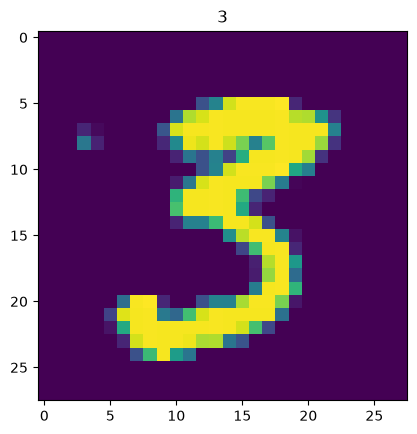

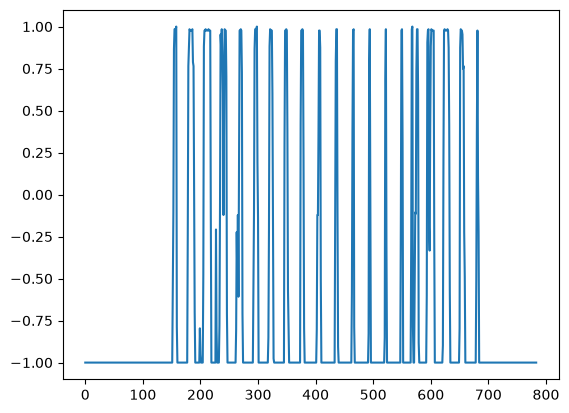

In [8]:
xi, yi=mnist_trainset[49]
xi.shape
img=xi[0,:,:].numpy()
plt.imshow(img)
plt.title(str(yi))

xi=xi.reshape(28*28,1)
plt.figure()
plt.plot(xi)

Ahora definiremos los parámetros del modelo, así como el modelo mismo

In [9]:
batch_size_train = 64
learning_rate = 0.01

model=torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(28*28,100),
    torch.nn.ReLU(),
    torch.nn.Linear(100,50),
    torch.nn.ReLU(),
    torch.nn.Linear(50,10),
    torch.nn.ReLU()
)

cross_el = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9) #e-1
epoch = 1000



In [10]:
import time
for epoch in range(epoch):
    start_time = time.time()
    for data in train_loader:      #for data in enumerate(train_loader):
        x, y = data                #    batch, (x,y)= data
        optimizer.zero_grad()
        output = model(x)
        loss = cross_el(output, y)
        loss.backward()
        optimizer.step()
    end_time = time.time()
    print(f'epoch: {epoch}, Error actual: {loss.item()}, Tiempo de proceso: {end_time-start_time}')

epoch: 0, Error actual: 2.2801222801208496, Tiempo de proceso: 12.708414554595947
epoch: 1, Error actual: 2.209184408187866, Tiempo de proceso: 13.018341541290283
epoch: 2, Error actual: 2.02204966545105, Tiempo de proceso: 14.692779541015625
epoch: 3, Error actual: 1.7036473751068115, Tiempo de proceso: 14.33713698387146
epoch: 4, Error actual: 1.4067416191101074, Tiempo de proceso: 14.334238290786743
epoch: 5, Error actual: 1.2697967290878296, Tiempo de proceso: 13.804309844970703
epoch: 6, Error actual: 1.1834139823913574, Tiempo de proceso: 14.210842847824097
epoch: 7, Error actual: 1.0955486297607422, Tiempo de proceso: 13.919991254806519
epoch: 8, Error actual: 1.0965412855148315, Tiempo de proceso: 13.319908142089844
epoch: 9, Error actual: 1.1217079162597656, Tiempo de proceso: 13.236562728881836
epoch: 10, Error actual: 1.0330729484558105, Tiempo de proceso: 14.466374397277832
epoch: 11, Error actual: 1.0918523073196411, Tiempo de proceso: 14.540028095245361
epoch: 12, Error a

KeyboardInterrupt: 

In [11]:
#Verificación del comportamiento del modelo
#Primero comprendamos el modelo.
x, y = next(iter(test_loader))
output = model(x)
print('Dimensión de la entrada: ',x.shape)
print('Dimensión del target: ',y.shape)
print('Dimensión de la salida: ',output.shape)

print('Target: ',y[0:4])
print('Salida de la red: ',output[0:4])
out=torch.argmax(output, dim=1)
print('Salida: ',out[0:4])

from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y.numpy(), out.numpy())
print(cm)

Dimensión de la entrada:  torch.Size([500, 1, 28, 28])
Dimensión del target:  torch.Size([500])
Dimensión de la salida:  torch.Size([500, 10])
Target:  tensor([0, 7, 8, 1])
Salida de la red:  tensor([[ 8.3006,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.7595,
          0.0000,  0.0000],
        [ 0.8916,  0.0000,  0.0000,  0.4220,  0.0000,  0.2717,  0.0000, 11.1085,
          0.0000,  3.1256],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000],
        [ 0.0000,  7.5694,  0.0000,  1.9461,  0.0000,  0.1173,  0.0000,  0.0000,
          0.0000,  0.0000]], grad_fn=<SliceBackward0>)
Salida:  tensor([0, 7, 0, 1])
[[52  0  0  0  0  0  0  0  0  0]
 [ 0 54  1  0  0  0  0  1  0  0]
 [ 0  0 48  1  0  0  0  0  0  1]
 [ 0  0  1 40  0  0  0  0  0  1]
 [41  1  1  0  0  1  0  0  0 12]
 [ 1  0  1  1  0 40  0  0  0  0]
 [47  0  5  0  0  2  0  1  0  0]
 [ 1  0  1  0  0  0  0 45  0  0]
 [42  2  2  3  0  2  0  1  0  1]
 [ 1  0  0  1  0  

In [12]:
#Ahora si una verificación un poco más seria
target=[]
pred=[]

for x, y in test_loader:
  output = model(x)
  out=torch.argmax(output, dim=1)
  target=target+list(y.numpy())
  pred=pred+list(out.numpy())

cm=confusion_matrix(target, pred, labels=[0,1,2,3,4,5,6,7,8,9])
print(cm)

#Por ejemplo las métricas respecto a la predicción del 0 o a cualquier otro valor
TP,TN,FP,FN=0,0,0,0
ref=0
for ti, pi in zip(target, pred):
  if(ti==ref and pi==ref):
    TP+=1
  if(ti==ref and pi!=ref):
    FN+=1
  if(ti!=ref and pi==ref):
    FP+=1
  if(ti!=ref and pi!=ref):
    TN+=1
print('TP: ',TP, ', TN: ',TN, ', FP: ',FP,', FN: ',FN)
print('Accuracy: ',(TP+TN)/(TP+TN+FP+FN))
TPR=TP/(TP+FN)
FPR=FP/(TN+FP)
print('TPR: ',TPR,', FPR: ',FPR)
TNR=1-FPR
print('Balanced Accuracy: ',(TPR+TNR)/2)


[[ 970    0    0    2    0    4    0    4    0    0]
 [   6 1117    4    3    0    3    0    2    0    0]
 [  25    2  981   10    0    1    0    8    0    5]
 [   9    0   14  951    0   12    0   10    0   14]
 [ 760    8   10    9    0   14    0   26    0  155]
 [  24    1    4   13    0  842    0    3    0    5]
 [ 853    2   31    2    0   62    0    7    0    1]
 [   6    7   24    5    0    1    0  969    0   16]
 [ 719   13   30   86    0   51    0   19    0   56]
 [  15    5    1   13    0   11    0   11    0  953]]
TP:  970 , TN:  6603 , FP:  2417 , FN:  10
Accuracy:  0.7573
TPR:  0.9897959183673469 , FPR:  0.267960088691796
Balanced Accuracy:  0.8609179148377755


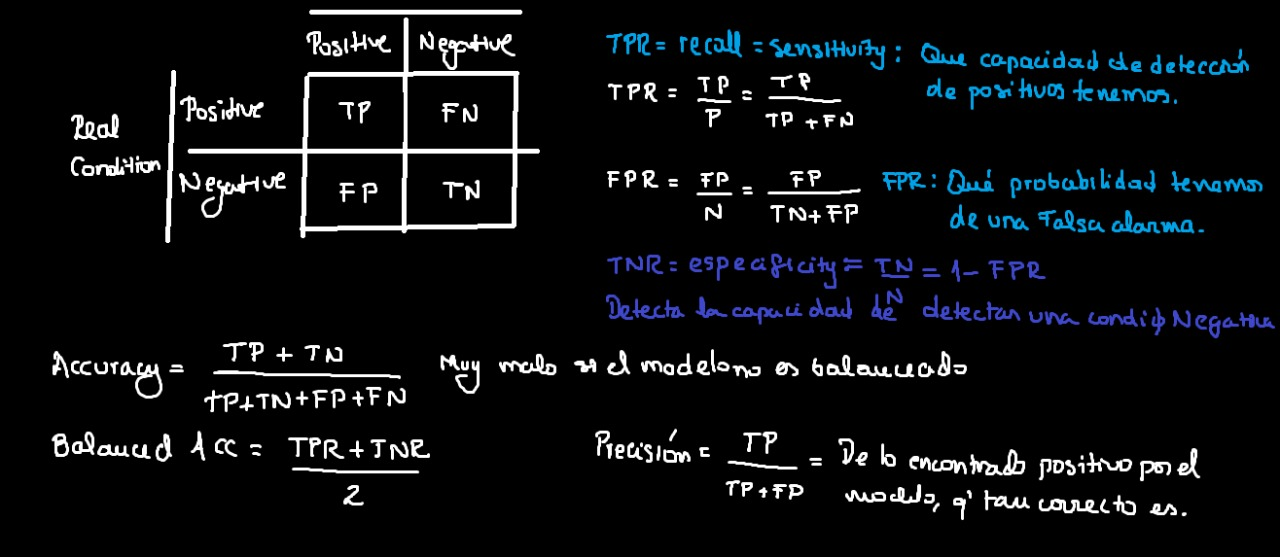